<a href="https://colab.research.google.com/github/MengOonLee/Deep_learning/blob/master/Experiments/Probabilistic/Bayesian/Bayesian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%bash
pip install --no-cache-dir -qU \
    torch torchvision lightning torchmetrics

# Probabilistic layers and Bayesian neural networks

## Coding tutorials
#### [1. The DistributionLambda layer](#coding_tutorial_1)
#### [2. Probabilistic layers](#coding_tutorial_2)
#### [3. The DenseVariational layer](#coding_tutorial_3)
#### [4. Reparameterization layers](#coding_tutorial_4)

***
<a id="coding_tutorial_1"></a>
## The `DistributionLambda` layer

#### Examples

In [ ]:
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)

class NormalModel(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(in_features=2, out_features=1)

    def forward(self, x: torch.Tensor):
        loc = self.linear(x)
        return torch.distributions.Normal(loc=loc, scale=1.0)

    def _nll(self, dist: torch.distributions, y_true: torch.Tensor):
        return -dist.log_prob(value=y_true).mean()

    def configure_optimizers(self):
        return torch.optim.RMSprop(params=self.parameters())

    @property
    def device(self):
        return next(self.parameters()).device

model = NormalModel()

x_sample = torch.randn(3, 2)
model.eval()
with torch.no_grad():
    dist = model(x=x_sample.to(model.device))

dist.mean

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


tensor([[-1.5611],
        [-0.1063],
        [-0.9046]])

#### Create a probabilistic model using the `DistributionLambda` layer

Create a model whose first layer represents:

$$
y = \text{sigmoid}(x) = \frac{1}{1 + \exp(-x)}.
$$

In [ ]:
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)

# Create a sigmoid model, first deterministic, then probabilistic
class BernoulliModel(pl.LightningModule):
    def __init__(self, kernel_init: float=1.0, bias_init: float=0.0,
            lr: float=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.linear = torch.nn.Linear(in_features=1, out_features=1)
        torch.nn.init.constant_(tensor=self.linear.weight, val=kernel_init)
        torch.nn.init.constant_(tensor=self.linear.bias, val=bias_init)

        # Track weights per epoch for plotting
        self.epoch_weights: list[float] = []
        self.epoch_biases: list[float] = []

    def forward(self, x: torch.Tensor):
        probs = torch.sigmoid(input=self.linear(x))
        return torch.distributions.Bernoulli(probs=probs)

    # Define negative loglikelihood
    def _nll(self, dist: torch.distributions, y_true: torch.Tensor):
        return -dist.log_prob(value=y_true).mean()

    def configure_optimizers(self):
        return torch.optim.RMSprop(params=self.parameters(),
            lr=self.hparams.lr)

    def training_step(self, batch, batch_idx):
        x, y_true = batch
        dist = self(x)
        loss = self._nll(dist=dist, y_true=y_true)
        self.log(name="train_loss", value=loss, on_step=False,
            on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        self.epoch_weights.append(self.linear.weight.item())
        self.epoch_biases.append(self.linear.bias.item())

    @property
    def device(self):
        return next(self.parameters()).device

true_model = BernoulliModel(kernel_init=1.0, bias_init=0.0)

# Create a constant input for this model
x_dummy = torch.zeros(1, 1)
dist = true_model(x=x_dummy.to(true_model.device))
print("Batch shape:", dist.batch_shape)
print("Event shape:", dist.event_shape)

# Explore the feedforward object...
# ... and its behaviour under repeated calls
true_model.eval()
with torch.no_grad():
    for _ in range(5):
        print(true_model(x=x_dummy.to(true_model.device))
            .sample().item())

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Batch shape: torch.Size([1, 1])
Event shape: torch.Size([])
1.0
0.0
1.0
0.0
1.0


#### Use the forward model to create probabilistic training data

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


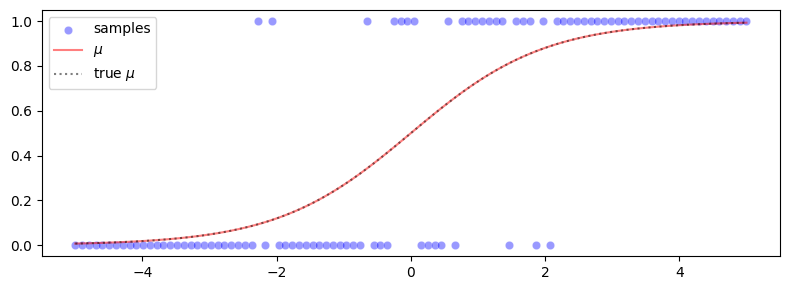

In [ ]:
import os
import numpy as np
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)
import matplotlib.pyplot as plt
import seaborn as sns

true_model = BernoulliModel(kernel_init=1.0, bias_init=0.0)

# Use the model to create 100 training points
x_train = torch.linspace(start=-5, end=5, steps=100, dtype=torch.float32)
x_train = x_train.view(*x_train.shape, 1)

true_model.eval()
with torch.no_grad():
    y_train = true_model(x=x_train.to(true_model.device)).sample()
    y_mean = true_model(x=x_train.to(true_model.device)).mean

class SyntheticDataModule(pl.LightningDataModule):
    def __init__(self, x: torch.Tensor, y: torch.Tensor,
            batch_size: int=16):
        super().__init__()
        self.batch_size = batch_size
        self._x = x
        self._y = y

    def setup(self, stage: str=None):
        self.ds_train = torch.utils.data.TensorDataset(self._x, self._y)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_train,
            shuffle=True, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    @property
    def x_numpy(self):
        return self._x.view(-1).numpy()

    @property
    def y_numpy(self):
        return self._y.view(-1).numpy()

if __name__ == "__main__":
    data_module = SyntheticDataModule(x=x_train, y=y_train)
    data_module.setup()

# Plot the data and the mean of the distribution
x_plt, y_plt = data_module.x_numpy, data_module.y_numpy
fig, ax = plt.subplots(figsize=(8, 3))
sns.scatterplot(ax=ax, x=x_plt, y=y_plt,
    color="blue", alpha=0.4, label="samples")
y_plt = y_mean.view(-1).numpy()
sns.lineplot(ax=ax, x=x_plt, y=y_plt,
    color="red", alpha=0.5, label=r"$\mu$")
sns.lineplot(ax=ax, x=x_plt, y=1/(1 + np.exp(-x_plt)),
    color="black", ls=":", alpha=0.5, label=r"true $\mu$")
ax.legend()
plt.tight_layout()
plt.show()

#### Create a new probabilistic model with the wrong weights,
#### train the new model with the negative loglikelihood.

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Number parameters: 2
Final weight: 1.1475
Final bias: -0.1112


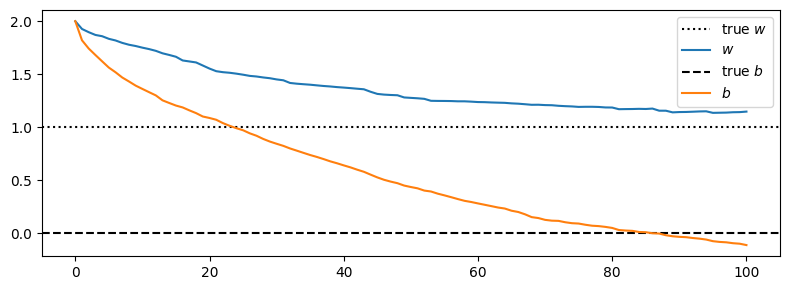

In [ ]:
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.WARNING)
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new version of the model, with the wrong weights
model = BernoulliModel(kernel_init=2.0, bias_init=2.0, lr=0.005)
print("Number parameters: %d"%(sum(p.numel() for p in model.parameters())))

initial_weight = model.linear.weight.item()
initial_bias = model.linear.bias.item()

trainer = pl.Trainer(max_epochs=100, accelerator="auto",
    enable_model_summary=False, enable_progress_bar=False, logger=False)

# Train model, record weights after each epoch
if __name__ == "__main__":
    trainer.fit(model=model, datamodule=data_module)

training_weights = [initial_weight] + model.epoch_weights
training_biases = [initial_bias] + model.epoch_biases
epochs = list(range(len(training_weights)))

print("Final weight: %.4f"%(training_weights[-1]))
print("Final bias: %.4f"%(training_biases[-1]))

# Plot the model weights after training, converging to the correct values
fig, ax = plt.subplots(figsize=(8, 3))
plt.axhline(y=1.0, label=r"true $w$", color="k", linestyle=":")
sns.lineplot(ax=ax, x=epochs, y=training_weights, label=r"$w$")
plt.axhline(y=0.0, label=r"true $b$", color="k", linestyle="--")
sns.lineplot(ax=ax, x=epochs, y=training_biases, label=r"$b$")
ax.legend()
plt.tight_layout()
plt.show()

***
<a id="coding_tutorial_2"></a>
## Probabilistic layers

#### Examples

In [ ]:
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)

class IndependentNormalModel(pl.LightningModule):
    def __init__(self, event_shape: tuple):
        super().__init__()
        self.event_shape = event_shape
        self.block = torch.nn.Sequential(
            torch.nn.Linear(in_features=4, out_features=16),
            torch.nn.ReLU(),
            # (batch_size, 2)
            torch.nn.Linear(in_features=16, out_features=2*event_shape[0])
        )

    def forward(self, x: torch.Tensor):
        x = self.block(x)
        # Split output into mean and log_std
        loc, scale = x.chunk(chunks=2, dim=-1)
        scale = torch.nn.functional.softplus(scale)
        normal = torch.distributions.Normal(loc=loc, scale=scale)
        return torch.distributions.Independent(base_distribution=normal,
            reinterpreted_batch_ndims=len(self.event_shape))

    @property
    def device(self):
        return next(self.parameters()).device

model = IndependentNormalModel(event_shape=(2,))

x_sample = torch.randn(100, 4) # x_sample: (100, 4)
model.eval()
with torch.no_grad():
    dist = model(x=x_sample.to(model.device))

print("Batch shape:", dist.batch_shape)
print("Event shape:", dist.event_shape)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Batch shape: torch.Size([100])
Event shape: torch.Size([2])


In [ ]:
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)

class CategoricalModel(pl.LightningModule):
    def __init__(self, num_classes: int, lr: float=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.backbone = torch.nn.Sequential(
            # (B, 16, 30, 30)
            torch.nn.Conv2d(in_channels=3, out_channels=16,
                kernel_size=(3, 3)),
            torch.nn.ReLU(),
            # (B, 16, 10, 10)
            torch.nn.MaxPool2d(kernel_size=(3, 3)),
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=1600, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=num_classes)
        )

    def forward(self, x: torch.Tensor):
        x = x.permute(0, 3, 1, 2)
        logits = self.backbone(x)
        return torch.distributions.OneHotCategorical(logits=logits)

    def _nll(self, dist: torch.distributions, y_true: torch.Tensor):
        """
        Negative log-likehood
        """
        return -dist.log_prob(value=y_true).mean()

    def configure_optimizers(self):
        return torch.optim.Adam(params=self.parameters(),
            lr=self.hparams.lr)

    @property
    def device(self):
        return next(self.parameters()).device

num_classes = 10
model = CategoricalModel(num_classes=num_classes, lr=0.01)

# x_test: (1, 32, 32, 3)
x_sample = torch.randn(1, 32, 32, 3)
model.eval()
with torch.no_grad():
    dist = model(x=x_sample.to(model.device))

print("Batch shape:", dist.batch_shape)
print("Event shape:", dist.event_shape)
print("Mean:", dist.mean)
print("Sample:", dist.sample())

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Batch shape: torch.Size([1])
Event shape: torch.Size([10])
Mean: tensor([[0.1466, 0.0911, 0.0824, 0.0735, 0.1066, 0.1455, 0.0739, 0.0887, 0.0789,
         0.1127]])
Sample: tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])


#### Create data

The data you'll be working with is artifically created from the following equation:
$$ y_i = x_i + \frac{3}{10}\epsilon_i$$
where $\epsilon_i \sim N(0, 1)$ are independent and identically distributed.

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


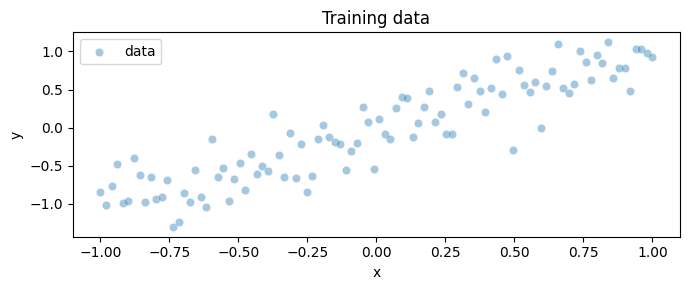

In [1]:
import os
import numpy as np
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)
import matplotlib.pyplot as plt
import seaborn as sns

# DataModule
class SyntheticDataModule(pl.LightningDataModule):
    def __init__(self, x: np.ndarray, y: np.ndarray, batch_size: int=16):
        super().__init__()
        self.batch_size = batch_size
        self._x = torch.from_numpy(x).view(*x.shape, 1)
        self._y = torch.from_numpy(y).view(*x.shape, 1)

    def setup(self, stage: str=None):
        ds = torch.utils.data.TensorDataset(self._x, self._y)

        if stage=="fit" or stage is None:
            self.ds_train, self.ds_val = torch.utils.data.random_split(
                dataset=ds, lengths=[0.9, 0.1],
                generator=torch.Generator().manual_seed(42))

        if stage in ["test", "predict"] or stage is None:
            self.ds_test = ds
            self.ds_predict = ds

    def train_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_train,
            shuffle=True, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_val,
            shuffle=False, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    def test_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_test,
            shuffle=False, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    def predict_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_predict,
            shuffle=False, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    @property
    def x_numpy(self):
        return self._x.view(-1).numpy()

    @property
    def y_numpy(self):
        return self._y.view(-1).numpy()

#Create and plot 100 points of training data
x_train = np.linspace(start=-1., stop=1., num=100, dtype=np.float32)
y_train = x_train + 0.3*np.random.randn(100).astype(np.float32)

if __name__ == "__main__":
    data_module = SyntheticDataModule(x=x_train, y=y_train)
    data_module.setup()

x_plt, y_plt = data_module.x_numpy, data_module.y_numpy
fig, ax = plt.subplots(figsize=(7, 3))
sns.scatterplot(ax=ax, x=x_plt, y=y_plt, label="data", alpha=0.4)
ax.legend()
ax.set(title="Training data", xlabel="x", ylabel="y")
plt.tight_layout()
plt.show()

#### Deterministic linear regression with MSE loss

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.07336126267910004    │
│          test_r2          │    0.8284453749656677     │
└───────────────────────────┴───────────────────────────┘

Training time: 4.6306s


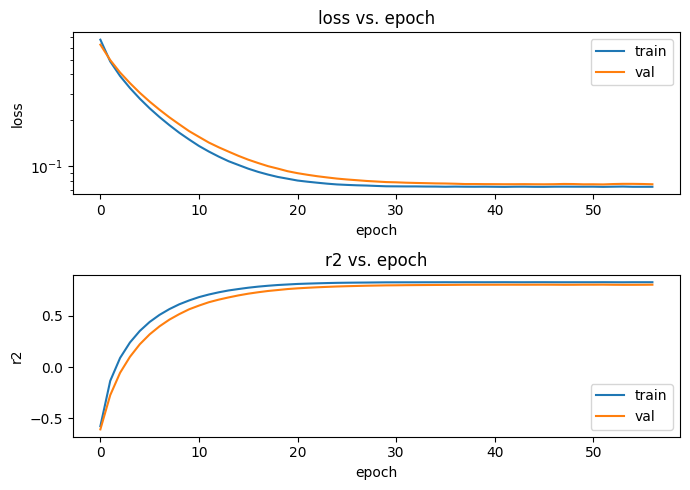

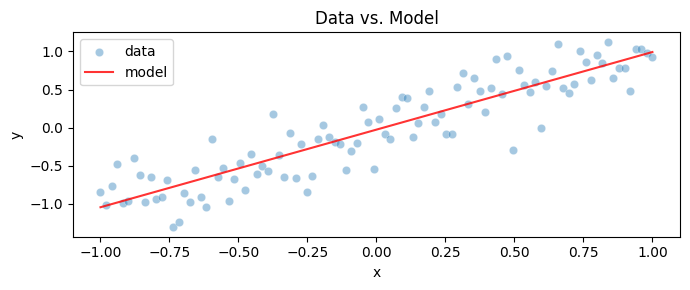

Predict at x=0: -0.026778


In [ ]:
import os
import shutil
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)
import torchmetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.WARNING)

# Create and train deterministic linear model using mean squared error loss
class LinearRegressionModel(pl.LightningModule):
    def __init__(self, lr: float=0.005):
        super().__init__()
        self.save_hyperparameters()
        self.linear = torch.nn.Linear(in_features=1, out_features=1)
        self.loss_fn = torch.nn.MSELoss()
        self.train_r2 = torchmetrics.R2Score()
        self.val_r2 = torchmetrics.R2Score()
        self.test_r2 = torchmetrics.R2Score()

    def forward(self, x: torch.Tensor):
        return self.linear(x)

    def _compute_loss(self, batch):
        """
        Return (loss, y_pred, y_true) for reuse across steps.
        """
        x, y_true = batch
        y_pred = self(x)
        loss = self.loss_fn(input=y_pred, target=y_true)
        return loss, y_pred, y_true

    def configure_optimizers(self):
        return torch.optim.RMSprop(params=self.parameters(),
            lr=self.hparams.lr)

    def training_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="train_loss", value=loss, on_step=False, on_epoch=True)
        self.train_r2.update(preds=y_pred.view(-1), target=y_true.view(-1))
        self.log(name="train_r2", value=self.train_r2, on_step=False,
            on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="val_loss", value=loss, on_step=False, on_epoch=True)
        self.val_r2.update(preds=y_pred.view(-1), target=y_true.view(-1))
        self.log(name="val_r2", value=self.val_r2, on_step=False,
            on_epoch=True)

    def test_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="test_loss", value=loss, on_step=False, on_epoch=True)
        self.test_r2.update(preds=y_pred.view(-1), target=y_true.view(-1))
        self.log(name="test_r2", value=self.test_r2, on_step=False,
            on_epoch=True)

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        return self(x)

    @property
    def device(self):
        return next(self.parameters()).device

model = LinearRegressionModel()

logs_dir = "./logs/linear_regression"
if os.path.exists(logs_dir):
    shutil.rmtree(logs_dir)
csv_logger = pl.loggers.CSVLogger(save_dir=logs_dir)

timer = pl.callbacks.Timer()

ckpt_dir = os.path.join(csv_logger.log_dir, "checkpoints")
model_checkpoint = pl.callbacks.ModelCheckpoint(monitor="val_loss",
    mode="min", dirpath=ckpt_dir, filename="best-{epoch}-{val_loss:.6f}",
    save_top_k=1, save_last=False)

early_stopping = pl.callbacks.EarlyStopping(monitor="val_loss",
    mode="min", patience=5)

trainer = pl.Trainer(max_epochs=100, accelerator="auto", logger=csv_logger,
    log_every_n_steps=1, enable_progress_bar=False,
    enable_model_summary=False,
    callbacks=[timer, model_checkpoint, early_stopping])

if __name__ == "__main__":
    trainer.fit(model=model, datamodule=data_module)
    trainer.test(model=model, datamodule=data_module, ckpt_path="best")
    predicts = trainer.predict(model=model, datamodule=data_module,
        ckpt_path="best")
    y_plt_pred = torch.cat(predicts, dim=0).view(-1).numpy()

print("Training time: %.4fs"%timer.time_elapsed("train"))

metrics_path = os.path.join(csv_logger.log_dir, "metrics.csv")
df_metrics = pd.read_csv(metrics_path).groupby("epoch", as_index=False)\
    .agg({
        "train_loss": "mean", "train_r2": "mean",
        "val_loss": "mean", "val_r2": "mean"
    })

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 5))
for ax, m in zip(axes, ["loss", "r2"]):
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"train_{m}",
        label="train")
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"val_{m}",
        label="val")
    if m=="loss":
        ax.set(title=f"{m} vs. epoch", xlabel="epoch", ylabel=f"{m}",
            yscale="log")
    else:
        ax.set(title=f"{m} vs. epoch", xlabel="epoch", ylabel=f"{m}")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Plot the data and model
fig, ax = plt.subplots(figsize=(7, 3))
sns.scatterplot(ax=ax, x=x_plt, y=y_plt, alpha=0.4, label="data")
sns.lineplot(ax=ax, x=x_plt, y=y_plt_pred, color="red", alpha=0.8,
    label="model")
ax.set(title="Data vs. Model", xlabel="x", ylabel="y")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Examine the model predictions
best_ckpt_path = model_checkpoint.best_model_path
model = LinearRegressionModel.load_from_checkpoint(
    checkpoint_path=best_ckpt_path)
model.eval()
with torch.no_grad():
    x_probe = torch.tensor([[0.]])
    print("Predict at x=0: %.6f"%model(x=x_probe.to(model.device)).item())

#### Probabilistic linear regression with both user-defined and learned variance

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.11214790493249893    │
│          test_r2          │    0.8284516930580139     │
└───────────────────────────┴───────────────────────────┘

Training time: 6.8557s


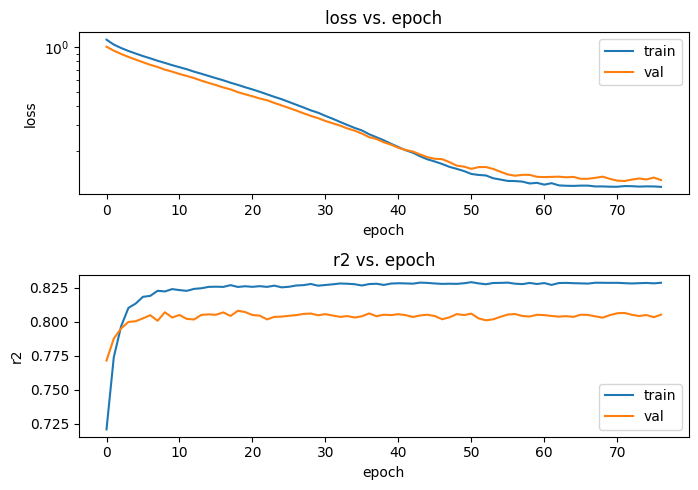

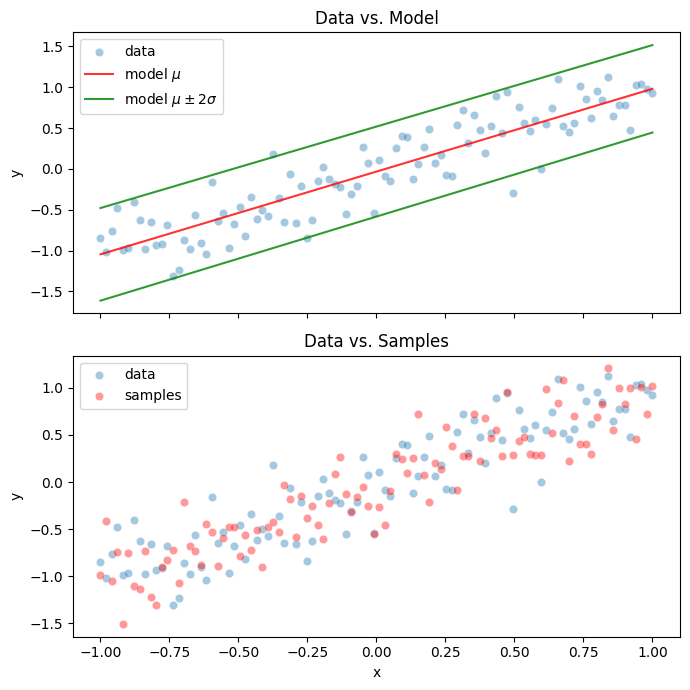

Predict at x=0: -0.032484


In [ ]:
import os
import shutil
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)
import torchmetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.WARNING)

# Create probabilistic regression with normal distribution as final layer
class ProbabilisticLinearRegressionModel(pl.LightningModule):
    def __init__(self, event_shape: tuple=(1,), lr: float=0.005):
        super().__init__()
        self.save_hyperparameters()
        self.linear = torch.nn.Linear(in_features=1,
            out_features=2*event_shape[0])
        self.train_r2 = torchmetrics.R2Score()
        self.val_r2 = torchmetrics.R2Score()
        self.test_r2 = torchmetrics.R2Score()

    def forward(self, x: torch.Tensor):
        x = self.linear(x)
        loc, scale = x.chunk(chunks=2, dim=-1)
        scale = torch.nn.functional.softplus(scale)
        normal = torch.distributions.Normal(loc=loc, scale=scale)
        return torch.distributions.Independent(base_distribution=normal,
            reinterpreted_batch_ndims=len(self.hparams.event_shape))

    def _compute_loss(self, batch):
        """
        Return (loss, y_pred, y_true) for reuse across steps.
        """
        x, y_true = batch
        dist = self(x)
        loss = -dist.log_prob(value=y_true).mean()
        y_pred = dist.mean
        return loss, y_pred, y_true

    def configure_optimizers(self):
        return torch.optim.RMSprop(params=self.parameters(),
            lr=self.hparams.lr)

    def training_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="train_loss", value=loss, on_step=False, on_epoch=True)
        self.train_r2.update(preds=y_pred.view(-1), target=y_true.view(-1))
        self.log(name="train_r2", value=self.train_r2, on_step=False,
            on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="val_loss", value=loss, on_step=False, on_epoch=True)
        self.val_r2.update(preds=y_pred.view(-1), target=y_true.view(-1))
        self.log(name="val_r2", value=self.val_r2, on_step=False,
            on_epoch=True)

    def test_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="test_loss", value=loss, on_step=False, on_epoch=True)
        self.test_r2.update(preds=y_pred.view(-1), target=y_true.view(-1))
        self.log(name="test_r2", value=self.test_r2, on_step=False,
            on_epoch=True)

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        dist = self(x)
        y_pred = dist.mean
        y_std = dist.stddev
        y_sample = dist.sample()
        return {
            "y_pred": y_pred,
            "y_std": y_std,
            "y_sample": y_sample
        }

    @property
    def device(self):
        return next(self.parameters()).device

model = ProbabilisticLinearRegressionModel()

logs_dir = "./logs/probabilistic_linear_regression"
if os.path.exists(logs_dir):
    shutil.rmtree(logs_dir)
csv_logger = pl.loggers.CSVLogger(save_dir=logs_dir)

timer = pl.callbacks.Timer()

ckpt_dir = os.path.join(csv_logger.log_dir, "checkpoints")
model_checkpoint = pl.callbacks.ModelCheckpoint(monitor="val_loss",
    mode="min", dirpath=ckpt_dir, filename="best-{epoch}-{val_loss:.6f}",
    save_top_k=1, save_last=False)

early_stopping = pl.callbacks.EarlyStopping(monitor="val_loss", mode="min",
    patience=5)

trainer = pl.Trainer(max_epochs=100, accelerator="auto", logger=csv_logger,
    log_every_n_steps=1, enable_progress_bar=False,
    enable_model_summary=False,
    callbacks=[timer, model_checkpoint, early_stopping])

# Train model using the negative loglikelihood
if __name__ == "__main__":
    trainer.fit(model=model, datamodule=data_module)
    trainer.test(model=model, datamodule=data_module, ckpt_path="best")
    predicts = trainer.predict(model=model, datamodule=data_module,
        ckpt_path="best")
    predicts = {k: torch.cat([p[k] for p in predicts], dim=0)
        .view(-1).numpy() for k in predicts[0].keys()}

print("Training time: %.4fs"%timer.time_elapsed("train"))

metrics_path = os.path.join(csv_logger.log_dir, "metrics.csv")
df_metrics = pd.read_csv(metrics_path).groupby("epoch", as_index=False)\
    .agg({
        "train_loss": "mean", "train_r2": "mean",
        "val_loss": "mean", "val_r2": "mean"
    })

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 5))
for ax, m in zip(axes, ["loss", "r2"]):
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"train_{m}",
        label="train")
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"val_{m}",
        label="val")
    if m=="loss":
        ax.set(title=f"{m} vs. epoch", xlabel="epoch", ylabel=f"{m}",
            yscale="log")
    else:
        ax.set(title=f"{m} vs. epoch", xlabel="epoch", ylabel=f"{m}")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Plot the data and a sample from the model
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(7, 7), sharex=True)
sns.scatterplot(ax=ax1, x=x_plt, y=y_plt, alpha=0.4, label="data")
sns.lineplot(ax=ax1, x=x_plt, y=predicts["y_pred"], color="red", alpha=0.8,
    label=r"model $\mu$")
sns.lineplot(ax=ax1, x=x_plt, y=predicts["y_pred"] - 2*predicts["y_std"],
    color="green", alpha=0.8, label=r"model $\mu \pm 2 \sigma$")
sns.lineplot(ax=ax1, x=x_plt, y=predicts["y_pred"] + 2*predicts["y_std"],
    color="green", alpha=0.8)
ax1.legend(loc="best")
ax1.set(title="Data vs. Model", xlabel="x", ylabel="y")

sns.scatterplot(ax=ax2, x=x_plt, y=y_plt, alpha=0.4, label="data")
sns.scatterplot(ax=ax2, x=x_plt, y=predicts["y_sample"], color="red",
    alpha=0.4, label="samples")
ax2.legend(loc="best")
ax2.set(title="Data vs. Samples", xlabel="x", ylabel="y")

plt.tight_layout()
plt.show()

# Examine the distribution created as a feedforward value
best_ckpt_path = model_checkpoint.best_model_path
model = ProbabilisticLinearRegressionModel.load_from_checkpoint(
    checkpoint_path=best_ckpt_path)
model.eval()
with torch.no_grad():
    x_probe = torch.tensor([[0.]])
    print("Predict at x=0: %.6f"%model(x=x_probe.to(model.device))
        .mean.item())

#### Probabilistic linear regression with nonlinear learned mean & variance

Let's change the data to being nonlinear:
$$ y_i = x_i^3 + \frac{1}{10}(2 + x_i)\epsilon_i$$
where $\epsilon_i \sim N(0, 1)$ are independent and identically distributed.

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


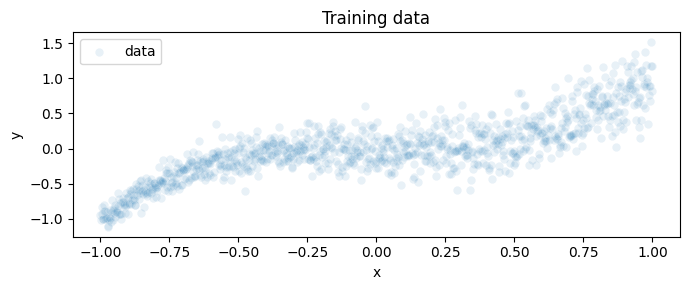

In [1]:
import os
import numpy as np
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)
import matplotlib.pyplot as plt
import seaborn as sns

class SyntheticDataModule(pl.LightningDataModule):
    def __init__(self, x: np.ndarray, y: np.ndarray, batch_size: int=32):
        super().__init__()
        self.batch_size = batch_size
        self._x = torch.from_numpy(x).view(*x.shape, 1)
        self._y = torch.from_numpy(y).view(*y.shape, 1)

    def setup(self, stage: str=None):
        ds = torch.utils.data.TensorDataset(self._x, self._y)

        if stage=="fit" or stage is None:
            self.ds_train, self.ds_val = torch.utils.data.random_split(
                dataset=ds, lengths=[0.9, 0.1],
                generator=torch.Generator().manual_seed(42))

        if stage in ["test", "predict"] or stage is None:
            self.ds_test = ds
            self.ds_predict = ds

    def train_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_train,
            shuffle=True, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_val,
            shuffle=False, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    def test_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_test,
            shuffle=False, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    def predict_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_test,
            shuffle=False, batch_size=self.batch_size,
            num_workers=os.cpu_count(), persistent_workers=True)

    @property
    def x_numpy(self):
        return self._x.view(-1).numpy()

    @property
    def y_numpy(self):
        return self._y.view(-1).numpy()

# Create and plot 1000 data points
x_train = np.linspace(start=-1., stop=1., num=1000, dtype=np.float32)
y_train = np.power(x_train, 3.) + 0.1*(2. + x_train)\
    *np.random.randn(*x_train.shape).astype(np.float32)

if __name__ == "__main__":
    dm = SyntheticDataModule(x=x_train, y=y_train)
    dm.setup()

x_plt, y_plt = dm.x_numpy, dm.y_numpy
fig, ax = plt.subplots(figsize=(7, 3))
sns.scatterplot(ax=ax, x=x_plt, y=y_plt, label="data", alpha=0.1)
ax.legend()
ax.set(title="Training data", xlabel="x", ylabel="y")
plt.tight_layout()
plt.show()

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dis

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   -0.19865599274635315    │
│          test_r2          │     0.748520016670227     │
└───────────────────────────┴───────────────────────────┘

INFO: Restoring states from the checkpoint path at /content/logs/probabilistic_regressor/lightning_logs/version_6/checkpoints/best-epoch=22-val_loss=-0.254866.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/logs/probabilistic_regressor/lightning_logs/version_6/checkpoints/best-epoch=22-val_loss=-0.254866.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/logs/probabilistic_regressor/lightning_logs/version_6/checkpoints/best-epoch=22-val_loss=-0.254866.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/logs/probabilistic_regressor/lightning_logs/version_6/checkpoints/best-epoch=22-val_loss=-0.254866.ckpt


Training time: 12.7329s


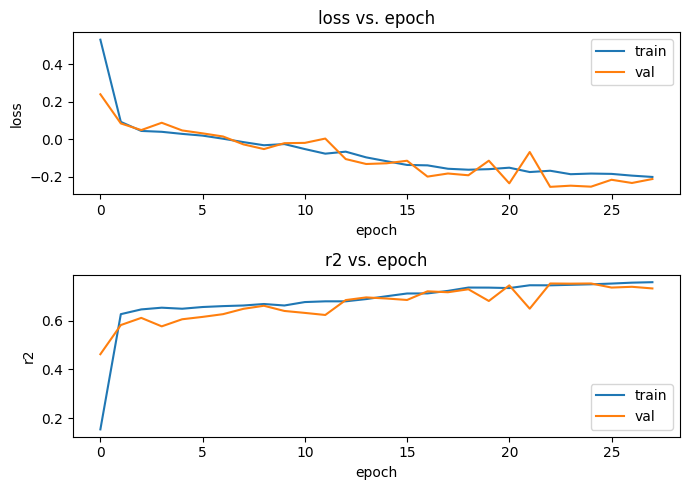

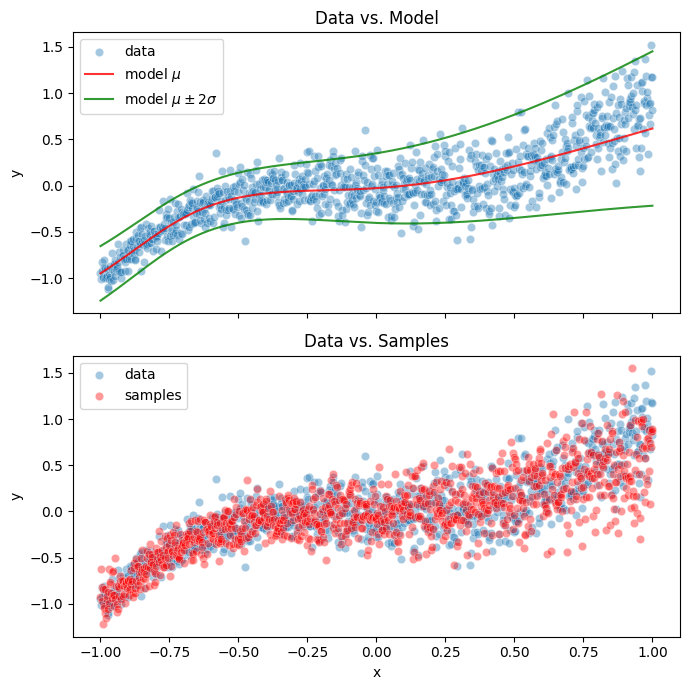

In [14]:
import os
import torch
import lightning.pytorch as pl
pl.seed_everything(seed=42, workers=True)
import torchmetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create probabilistic regression: normal distribution with fixed variance
class ProbabilisticRegressor(pl.LightningModule):
    def __init__(self, event_shape: int=(1,), lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.linear01 = torch.nn.Linear(in_features=1,
            out_features=32)
        self.linear02 = torch.nn.Linear(in_features=32,
            out_features=32)
        self.linear03 = torch.nn.Linear(in_features=32,
            out_features=2*event_shape[0])
        self.train_r2 = torchmetrics.R2Score()
        self.val_r2 = torchmetrics.R2Score()
        self.test_r2 = torchmetrics.R2Score()

    def forward(self, x: torch.Tensor):
        x = torch.nn.functional.tanh(self.linear01(x))
        x = torch.nn.functional.tanh(self.linear02(x))
        x = self.linear03(x)
        loc, log_scale = x.chunk(chunks=2, dim=-1)
        loc = torch.clamp(input=loc, min=-10.0, max=10.0)
        log_scale = torch.clamp(input=log_scale, min=-3.0, max=1.0)
        scale = torch.exp(log_scale)
        normal = torch.distributions.Normal(loc=loc, scale=scale)
        return torch.distributions.Independent(base_distribution=normal,
            reinterpreted_batch_ndims=len(self.hparams.event_shape))

    def _compute_loss(self, batch):
        x, y_true = batch
        dist = self(x)
        y_pred = dist.mean

        if not torch.isfinite(y_pred).all():
            print(f"NON-FINITE y_pred! min={y_pred.min().item()}, max={y_pred.max().item()}")

        loss = -dist.log_prob(value=y_true)
        loss = torch.nan_to_num(loss, nan=10.0, posinf=10.0, neginf=10.0)
        loss = loss.mean()
        if not torch.isfinite(loss):
            print(f"NON-FINITE loss: {loss.item()}")
        return loss, y_pred, y_true

    def on_after_backward(self):
        for p in self.parameters():
            if p.grad is not None:
                torch.nan_to_num_(input=p.grad, nan=0.0,
                    posinf=0.0, neginf=0.0)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(params=self.parameters(),
            lr=self.hparams.lr, eps=1e-7, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer, mode="min", patience=5, factor=0.9)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

    def training_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="train_loss", value=loss,
            on_step=False, on_epoch=True)

        y_pred_safe = torch.nan_to_num(y_pred, nan=0.0, posinf=1e4, neginf=-1e4)
        self.train_r2.update(preds=y_pred_safe.view(-1),
            target=y_true.view(-1))
        self.log(name="train_r2", value=self.train_r2,
            on_step=False, on_epoch=True)
        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx):
        with torch.no_grad():
            for p in self.parameters():
                if not torch.isfinite(p).all():
                    torch.nan_to_num_(p, nan=0.0, posinf=1e3, neginf=-1e3)

    def on_train_epoch_end(self):
        for name, p in self.named_parameters():
            if not torch.isfinite(p).all():
                print(f"NON-FINITE WEIGHT: {name}")

    def validation_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="val_loss", value=loss,
            on_step=False, on_epoch=True)

        y_pred_safe = torch.nan_to_num(y_pred, nan=0.0, posinf=1e4, neginf=-1e4)
        self.val_r2.update(preds=y_pred_safe.view(-1),
            target=y_true.view(-1))
        self.log(name="val_r2", value=self.val_r2,
            on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        loss, y_pred, y_true = self._compute_loss(batch)
        self.log(name="test_loss", value=loss,
            on_step=False, on_epoch=True)

        y_pred_safe = torch.nan_to_num(y_pred, nan=0.0, posinf=1e4, neginf=-1e4)
        self.test_r2.update(preds=y_pred_safe.view(-1),
            target=y_true.view(-1))
        self.log(name="test_r2", value=self.test_r2,
            on_step=False, on_epoch=True)

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        dist = self(x)
        return {
            "y_pred": dist.mean,
            "y_std": dist.stddev,
            "y_sample": dist.sample()
        }

    @property
    def device(self):
        return next(self.parameters()).device

model = ProbabilisticRegressor(event_shape=(1,), lr=1e-3)

logs_dir = "./logs/probabilistic_regressor"
csv_logger = pl.loggers.CSVLogger(save_dir=logs_dir)

ckpt_dir = os.path.join(csv_logger.log_dir, "checkpoints")
model_checkpoint = pl.callbacks.ModelCheckpoint(monitor="val_loss",
    mode="min", dirpath=ckpt_dir, filename="best-{epoch}-{val_loss:.6f}",
    save_top_k=1, save_last=False)

early_stopping = pl.callbacks.EarlyStopping(monitor="val_loss",
    mode="min", patience=5)

timer = pl.callbacks.Timer()

trainer = pl.Trainer(max_epochs=100, accelerator="auto",
    logger=csv_logger, log_every_n_steps=1,
    enable_progress_bar=False, enable_model_summary=False,
    gradient_clip_val=1.0,
    callbacks=[model_checkpoint, early_stopping, timer])

# Train model
if __name__ == "__main__":
    torch.autograd.set_detect_anomaly(True)
    trainer.fit(model=model, datamodule=dm)
    trainer.test(model=model, datamodule=dm, ckpt_path="best")
    predicts = trainer.predict(model=model, datamodule=dm,
        ckpt_path="best")

print("Training time: %.4fs"%timer.time_elapsed("train"))

metrics_path = os.path.join(csv_logger.log_dir, "metrics.csv")
df_metrics = pd.read_csv(metrics_path).groupby("epoch", as_index=False)\
    .agg({
        "train_loss": "mean", "train_r2": "mean",
        "val_loss": "mean", "val_r2": "mean"
    })

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 5))
for ax, m in zip(axes, ["loss", "r2"]):
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"train_{m}",
        label="train")
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"val_{m}",
        label="val")
    ax.set(title=f"{m} vs. epoch", xlabel="epoch", ylabel=f"{m}")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Plot the data and a sample from the model
predicts = {k: torch.cat([p[k] for p in predicts], dim=0).view(-1).numpy()
    for k in predicts[0].keys()}
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(7, 7), sharex=True)
sns.scatterplot(ax=ax1, x=x_plt, y=y_plt, alpha=0.4, label="data")
sns.lineplot(ax=ax1, x=x_plt, y=predicts["y_pred"], label=r"model $\mu$",
    color="red", alpha=0.8)
sns.lineplot(ax=ax1, x=x_plt, y=predicts["y_pred"] - 2*predicts["y_std"],
    label=r"model $\mu \pm 2 \sigma$", color="green", alpha=0.8)
sns.lineplot(ax=ax1, x=x_plt, y=predicts["y_pred"] + 2*predicts["y_std"],
    color="green", alpha=0.8)
ax1.legend(loc="best")
ax1.set(title="Data vs. Model", xlabel="x", ylabel="y")

sns.scatterplot(ax=ax2, x=x_plt, y=y_plt, label="data",
    alpha=0.4)
sns.scatterplot(ax=ax2, x=x_plt, y=predicts["y_sample"], label="samples",
    color="red", alpha=0.4)
ax2.legend(loc="best")
ax2.set(title="Data vs. Samples", xlabel="x", ylabel="y")

plt.tight_layout()
plt.show()

In [15]:
df_metrics

,epoch,train_loss,train_r2,val_loss,val_r2
0,0,0.530915,0.154399,0.239447,0.462135
1,1,0.092041,0.626130,0.083792,0.581543
2,2,0.043730,0.645564,0.048348,0.610873
3,3,0.039102,0.652598,0.087395,0.576199
4,4,0.027996,0.648340,0.046406,0.605225
5,5,0.018704,0.655366,0.030861,0.614925
6,6,0.002194,0.659065,0.014085,0.626108
7,7,-0.015985,0.661628,-0.028145,0.648018
8,8,-0.032640,0.667661,-0.053108,0.660524
9,9,-0.026425,0.661601,-0.021684,0.639240


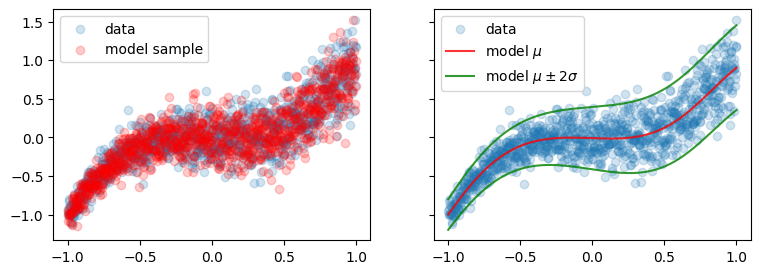

In [ ]:
import matplotlib.pyplot as plt

# Plot the data and a sample from the model

y_model = model(inputs=x_train)
y_sample = y_model.sample()
y_hat = y_model.mean()
y_sd = y_model.stddev()
y_hat_m2sd = y_hat - 2 * y_sd
y_hat_p2sd = y_hat + 2 * y_sd

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 3),
    sharey=True)
ax1.scatter(x=x_train, y=y_train, alpha=0.2, label='data')
ax1.scatter(x=x_train, y=y_sample, alpha=0.2, color='red',
    label='model sample')
ax1.legend()
ax2.scatter(x=x_train, y=y_train, alpha=0.2, label='data')
ax2.plot(x_train, y_hat, color='red', alpha=0.8, label='model $\mu$')
ax2.plot(x_train, y_hat_m2sd, color='green', alpha=0.8,
    label='model $\mu \pm 2 \sigma$')
ax2.plot(x_train, y_hat_p2sd, color='green', alpha=0.8)
ax2.legend()
plt.show()

***
<a id="coding_tutorial_3"></a>
## The `DenseVariational` layer

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    return lambda t: tfp.distributions.Independent(distribution=
        tfp.distributions.Normal(scale=1, loc=tf.zeros(shape=n, dtype=dtype)),
        reinterpreted_batch_ndims=1)

def posterior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    return tf_keras.Sequential(layers=[
        tfp.layers.VariableLayer(dtype=dtype,
            shape=tfp.layers.IndependentNormal.params_size(event_shape=n)),
        tfp.layers.IndependentNormal(event_shape=n,
            convert_to_tensor_fn=tfp.distributions.Distribution.sample)
    ])

# ELBO:
# q = q(w | theta)
# E_{w ~ q}[log p(D | w)] - KL[q || p]
#     = Sum_i E_{w ~ q}[log p(D_i | w)] - KL[q || p]

# For a minibatch:
# N/B * Sum_j E_{w ~ q}[log p(D_j | w)] - KL[q || p]

# Per example loss:
# 1/B * Sum_j E_{w ~q}[log p(D_j | w)] - 1/N * KL[q || p]

N=1000
model = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=(8,)),
    tfp.layers.DenseVariational(units=16,
        activation=tf.keras.activations.relu,
        make_prior_fn=prior, make_posterior_fn=posterior,
        kl_weight=1/N, kl_use_exact=True),
    tfp.layers.DenseVariational(units=2,
        make_prior_fn=prior, make_posterior_fn=posterior,
        kl_weight=1/N, kl_use_exact=True),
    tfp.layers.IndependentNormal(event_shape=1)
])

model.compile(
    loss=lambda y_true, y_pred: -y_pred.log_prob(value=y_true),
    optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.005)
)

x_test = tf.random.uniform(shape=(2, 8), dtype=tf.float32)
model(inputs=x_test).mean()

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.2444477],
       [2.8562212]], dtype=float32)>

#### Create linear data with Gaussian noise

The data you'll be working with is the same as you used before:
$$ y_i = x_i + \frac{3}{10}\epsilon_i$$
where $\epsilon_i \sim N(0, 1)$ are independent and identically distributed. We'll be running a Bayesian linear regression on this data.

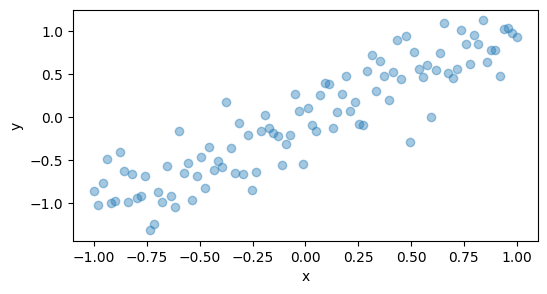

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(seed=42)

# Use the same data as before -- create and plot 100 data points

x_train = np.linspace(start=-1, stop=1, num=100, dtype=np.float32)
y_train = x_train + 0.3*np.random.randn(100).astype(np.float32)

plt.figure(figsize=(6, 3))
plt.scatter(x=x_train, y=y_train, alpha=0.4)
plt.xlabel(xlabel='x')
plt.ylabel(ylabel='y')
plt.show()

#### Create the prior and posterior distribution for model weights

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

# Define the prior weight distribution -- all N(0, 1) -- and not trainable

def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    prior_model = tf_keras.Sequential(layers=[
        tfp.layers.DistributionLambda(make_distribution_fn=
            lambda _: tfp.distributions.MultivariateNormalDiag(
                loc=tf.zeros(shape=n), scale_diag=tf.ones(shape=n)))
    ])
    return prior_model

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

# Define variational posterior weight distribution -- multivariate Gaussian

def posterior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    posterior_model = tf_keras.Sequential(layers=[
        tfp.layers.VariableLayer(dtype=dtype,
            shape=tfp.layers.MultivariateNormalTriL.params_size(event_size=n)),
        tfp.layers.MultivariateNormalTriL(event_size=n)
    ])
    return posterior_model

#### Aside: analytical posterior

In this tutorial, we're using a variational posterior because, in most settings, it's not possible to derive an analytical one. However, in this simple setting, it is possible. Specifically, running a Bayesian linear regression on $x_i$ and $y_i$ with $i=1, \ldots, n$ and a unit Gaussian prior on both $\alpha$ and $\beta$:

$$
y_i = \alpha + \beta x_i + \epsilon_i, \quad
\epsilon_i \sim N(0, \sigma^2), \quad
\alpha \sim N(0, 1), \quad
\beta \sim N(0, 1)
$$

gives a multivariate Gaussian posterior on $\alpha$ and $\beta$:

$$
\begin{pmatrix}
\alpha \\
\beta
\end{pmatrix}
\sim
N(\mathbf{\mu}, \mathbf{\Sigma})
$$
where
$$
\mathbf{\mu}
=
\mathbf{\Sigma}
\begin{pmatrix}
\hat{n} \bar{y} \\
\hat{n} \overline{xy}
\end{pmatrix},
\quad
\mathbf{\Sigma} =
\frac{1}{(\hat{n} + 1)(\hat{n} \overline{x^2} + 1) - \hat{n}^2 \bar{x}^2}
\begin{pmatrix}
\hat{n} \overline{x^2} + 1 & -\hat{n} \bar{x} \\
-\hat{n} \bar{x} & \hat{n} + 1
\end{pmatrix}.
$$

In the above, $\hat{n} = \frac{n}{\sigma^2}$ and $\bar{t} = \frac{1}{n}\sum_{i=1}^n t_i$ for any $t$. In general, however, it's not possible to determine the analytical form for the posterior. For example, in models with a hidden layer with nonlinear activation function, the analytical posterior cannot be determined in general, and variational methods as below are useful.

#### Create the model with `DenseVariational` layers

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

# Create linear regression model with weight uncertainty: weights are
# distributed according to posterior (and, indirectly, prior) distribution

model = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=(1,)),
    tfp.layers.DenseVariational(units=1,
        make_prior_fn=prior, make_posterior_fn=posterior,
        kl_weight=1/x_train.shape[0], kl_use_exact=True)
])

model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.005)
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_variational (DenseVa  (None, 1)                 5         
 riational)                                                      
                                                                 
Total params: 5 (20.00 Byte)
Trainable params: 5 (20.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Train model and inspect

In [ ]:
# Fit the model, just like a deterministic linear regression
model.fit(x=x_train, y=y_train, epochs=500, verbose=False)

In [ ]:
import numpy as np

# Check out the parameters of the prior and posterior distribution

dummy_input = np.array([0], dtype=np.float32)
model_prior = model.layers[0]._prior(dummy_input)
model_posterior = model.layers[0]._posterior(dummy_input)
print('prior mean:           ', model_prior.mean().numpy())
print('prior variance:       ', model_prior.variance().numpy())
print('posterior mean:       ', model_posterior.mean().numpy())
print('posterior stddev:     ', model_posterior.stddev().numpy())
print('posterior covariance: ', model_posterior.covariance().numpy()[0])
print('                      ', model_posterior.covariance().numpy()[1])

prior mean:            [0. 0.]
prior variance:        [1. 1.]
posterior mean:        [ 1.01274   -0.0243581]
posterior stddev:      [0.1338573  0.08085433]
posterior covariance:  [0.01791777 0.00302092]
                       [0.00302092 0.00653742]


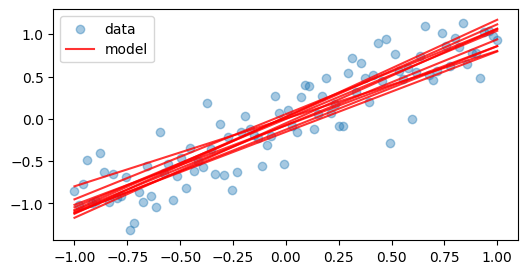

In [ ]:
import matplotlib.pyplot as plt

# Plot an ensemble of linear regressions, with weights sampled from
# the posterior distribution

plt.figure(figsize=(6, 3))
plt.scatter(x=x_train, y=y_train, alpha=0.4, label='data')
for _ in range(10):
    y_model = model(inputs=x_train)
    if _ == 0:
        plt.plot(x_train, y_model, color='red', alpha=0.8,
            label='model')
    else:
        plt.plot(x_train, y_model, color='red', alpha=0.8)
plt.legend()
plt.show()

#### Explore the effect of sample size

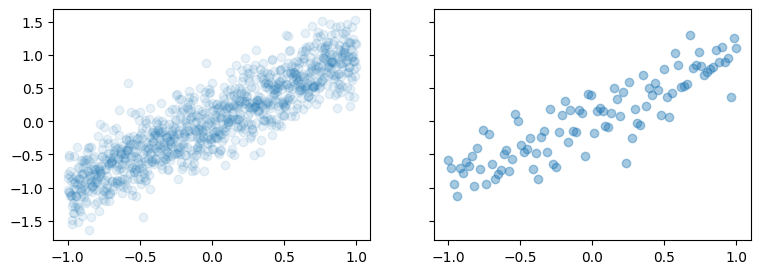

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(seed=42)

# Create two datasets, one with 1000 points, another with 100

x_train_1000 = np.linspace(start=-1, stop=1, num=1000, dtype=np.float32)
y_train_1000 = x_train_1000 + 0.3*np.random.randn(1000).astype(np.float32)

x_train_100 = np.linspace(start=-1, stop=1, num=100, dtype=np.float32)
y_train_100 = x_train_100 + 0.3*np.random.randn(100).astype(np.float32)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 3),
    sharex=True, sharey=True)
ax1.scatter(x=x_train_1000, y=y_train_1000, alpha=0.1)
ax2.scatter(x=x_train_100, y=y_train_100, alpha=0.4)
plt.show()

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

# Train a model on each dataset

def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    prior_model = tf_keras.Sequential(layers=[
        tfp.layers.DistributionLambda(make_distribution_fn=
            lambda _: tfp.distributions.MultivariateNormalDiag(
                loc=tf.zeros(shape=n), scale_diag=tf.ones(shape=n)))
    ])
    return prior_model

def posterior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    posterior_model = tf_keras.Sequential(layers=[
        tfp.layers.VariableLayer(dtype=dtype,
            shape=tfp.layers.MultivariateNormalTriL.params_size(event_size=n)),
        tfp.layers.MultivariateNormalTriL(event_size=n)
    ])
    return posterior_model

model_1000 = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=(1,)),
    tfp.layers.DenseVariational(units=1,
        make_prior_fn=prior, make_posterior_fn=posterior,
        kl_weight=1/x_train_1000.shape[0])
])

model_100 = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=(1,)),
    tfp.layers.DenseVariational(units=1,
        make_prior_fn=prior, make_posterior_fn=posterior,
        kl_weight=1/x_train_100.shape[0])
])

model_1000.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.005)
)

model_100.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.005)
)

model_1000.fit(x=x_train_1000, y=y_train_1000, epochs=50,
    verbose=False)

model_100.fit(x=x_train_100, y=y_train_100, epochs=500,
    verbose=False)

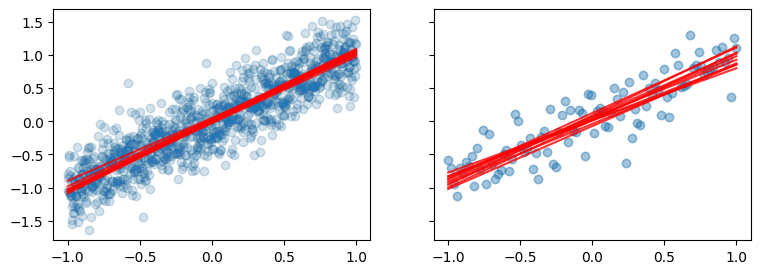

In [ ]:
import matplotlib.pyplot as plt

# Plot an ensemble of linear regressions from each model

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 3),
    sharex=True, sharey=True)

for _ in range(10):
    y_model_1000 = model_1000(inputs=x_train_1000)
    ax1.scatter(x=x_train_1000, y=y_train_1000, color='C0', alpha=0.02)
    ax1.plot(x_train_1000, y_model_1000, color='red', alpha=0.8)

    y_model_100 = model_100(inputs=x_train_100)
    ax2.scatter(x=x_train_100, y=y_train_100, color='C0', alpha=0.05)
    ax2.plot(x_train_100, y_model_100, color='red', alpha=0.8)

plt.show()

#### Put it all together: nonlinear probabilistic regression with weight uncertainty

Let's change the data to being nonlinear:
$$ y_i = x_i^3 + \frac{1}{10}(2 + x_i)\epsilon_i $$
where $\epsilon_i \sim N(0, 1)$ are independent and identically distributed.

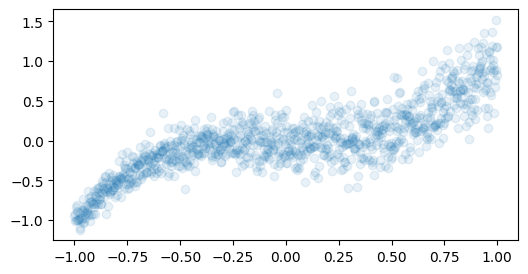

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(seed=42)

# Create and plot 1000 data points

x_train = np.linspace(start=-1, stop=1, num=1000, dtype=np.float32)
y_train = np.power(x_train, 3) + 0.1*(2 + x_train)\
    *np.random.randn(1000).astype(np.float32)

plt.figure(figsize=(6, 3))
plt.scatter(x=x_train, y=y_train, alpha=0.1)
plt.show()

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

# Create probabilistic regression with one hidden layer, weight uncertainty

def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    prior_model = tf_keras.Sequential(layers=[
        tfp.layers.DistributionLambda(make_distribution_fn=
            lambda _: tfp.distributions.MultivariateNormalDiag(
                loc=tf.zeros(shape=n), scale_diag=tf.ones(shape=n)))
    ])
    return prior_model

def posterior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    posterior_model = tf_keras.Sequential(layers=[
        tfp.layers.VariableLayer(dtype=dtype,
            shape=tfp.layers.MultivariateNormalTriL.params_size(event_size=n)),
        tfp.layers.MultivariateNormalTriL(event_size=n)
    ])
    return posterior_model

event_shape = 1
model = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=(1,)),
    tfp.layers.DenseVariational(units=8,
        activation=tf.keras.activations.sigmoid,
        make_prior_fn=prior, make_posterior_fn=posterior,
        kl_weight=1/x_train.shape[0]),
    tfp.layers.DenseVariational(
        units=tfp.layers.IndependentNormal.params_size(event_shape=event_shape),
        make_prior_fn=prior, make_posterior_fn=posterior,
        kl_weight=1/x_train.shape[0]),
    tfp.layers.IndependentNormal(event_shape=event_shape)
])

def nll(y_true, y_pred):
    return -y_pred.log_prob(value=y_true)

model.compile(
    loss=nll,
    optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.01)
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_variational (DenseVa  (None, 8)                 152       
 riational)                                                      
                                                                 
 dense_variational_1 (Dense  (None, 2)                 189       
 Variational)                                                    
                                                                 
 independent_normal (Indepe  ((None, 1),               0         
 ndentNormal)                 (None, 1))                         
                                                                 
Total params: 341 (1.33 KB)
Trainable params: 341 (1.33 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Train the model
model.fit(x=x_train, y=y_train, epochs=1000, verbose=False)
model.evaluate(x=x_train, y=y_train, verbose=False)

0.11501187831163406

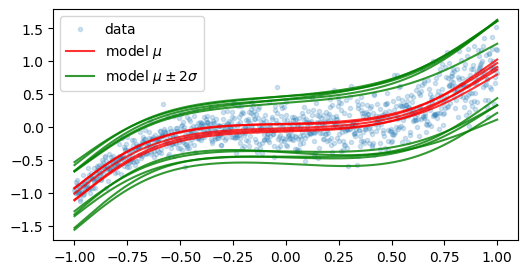

In [ ]:
import matplotlib.pyplot as plt

# Plot an ensemble of trained probabilistic regressions

plt.figure(figsize=(6, 3))
plt.scatter(x=x_train, y=y_train, marker='.', alpha=0.2, label='data')
for _ in range(5):
    y_model = model(inputs=x_train)
    y_hat = y_model.mean()
    y_hat_m2sd = y_hat - 2 * y_model.stddev()
    y_hat_p2sd = y_hat + 2 * y_model.stddev()
    if _ == 0:
        plt.plot(x_train, y_hat, color='red', alpha=0.8,
            label='model $\mu$')
        plt.plot(x_train, y_hat_m2sd, color='green', alpha=0.8,
            label='model $\mu \pm 2 \sigma$')
        plt.plot(x_train, y_hat_p2sd, color='green', alpha=0.8)
    else:
        plt.plot(x_train, y_hat, color='red', alpha=0.8)
        plt.plot(x_train, y_hat_m2sd, color='green', alpha=0.8)
        plt.plot(x_train, y_hat_p2sd, color='green', alpha=0.8)
plt.legend()
plt.show()

***
<a id="coding_tutorial_4"></a>
## Reparameterization layers

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

def custom_multivariate_normal_fn(dtype, shape, name, trainable, add_variable_fn):
    normal = tfp.distributions.Normal(
        loc=tf.zeros(shape=shape, dtype=dtype),
        scale=2*tf.ones(shape=shape, dtype=dtype))
    batch_ndims = tf.size(input=normal.batch_shape_tensor())
    return tfp.distributions.Independent(distribution=normal,
        reinterpreted_batch_ndims=batch_ndims)

dataset_size = 1000
event_size = 10
model = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=(28, 28, 1)),
    tfp.layers.Convolution2DReparameterization(filters=16, kernel_size=(3, 3),
        activation=tf.keras.activations.relu,
        kernel_prior_fn=custom_multivariate_normal_fn,
        kernel_posterior_fn=tfp.layers.default_mean_field_normal_fn(),
        kernel_posterior_tensor_fn=tfp.distributions.Distribution.sample,
        kernel_divergence_fn=(lambda q, p, _: tfp.distributions.kl_divergence(
            distribution_a=q, distribution_b=p) / dataset_size),
        bias_prior_fn=None,
        bias_posterior_fn=tfp.layers.default_mean_field_normal_fn(is_singular=True),
        bias_posterior_tensor_fn=tfp.distributions.Distribution.sample),
    tf_keras.layers.MaxPool2D(pool_size=(3, 3)),
    tf_keras.layers.Flatten(),
    tfp.layers.DenseReparameterization(units=tfp.layers.OneHotCategorical
        .params_size(event_size=event_size)),
    tfp.layers.OneHotCategorical(event_size=event_size)
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_reparameterization_  (None, 26, 26, 16)        304       
 1 (Conv2DReparameterizatio                                      
 n)                                                              
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 16)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 1024)              0         
                                                                 
 dense_reparameterization_1  (None, 10)                20490     
  (DenseReparameterization)                                      
                                                                 
 one_hot_categorical_1 (One  ((None, 10),             

#### Load in the HAR dataset

You'll be working with the [Human Activity Recognition (HAR) Using Smartphones](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) dataset. It consists of the readings from an accelerometer (which measures acceleration) carried by a human doing different activities. The six activities are walking horizontally, walking upstairs, walking downstairs, sitting, standing and laying down. The accelerometer is inside a smartphone, and, every 0.02 seconds (50 times per second), it takes six readings: linear and gyroscopic acceleration in the x, y and z directions. See [this link](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) for details and download. If you use it in your own research, please cite the following paper:

- Davide Anguita, Alessandro Ghio, Luca Oneto, Xavier Parra and Jorge L. Reyes-Ortiz. A Public Domain Dataset for Human Activity Recognition Using Smartphones. 21th European Symposium on Artificial Neural Networks, Computational Intelligence and Machine Learning, ESANN 2013. Bruges, Belgium 24-26 April 2013.

The goal is to use the accelerometer data to predict the activity.

In [ ]:
import numpy as np
np.random.seed(seed=42)
import os

# Load the HAR dataset and create some data processing functions

# Function to load the data from file
def load_HAR_data():
    data_dir = 'HAR/'
    x_train = np.load(file=os.path.join(data_dir, 'x_train.npy'))[..., :6]
    x_train = x_train.astype(np.float32)
    y_train = np.load(file=os.path.join(data_dir, 'y_train.npy')) - 1
    y_train = y_train.astype(np.int32)
    x_test  = np.load(file=os.path.join(data_dir, 'x_test.npy'))[..., :6]
    x_test  = x_test.astype(np.float32)
    y_test  = np.load(file=os.path.join(data_dir, 'y_test.npy')) - 1
    y_test  = y_test.astype(np.int32)
    return (x_train, y_train), (x_test, y_test)

# Dictionary containing the labels and the associated activities
label_to_activity = {0: 'walking horizontally', 1: 'walking upstairs',
    2: 'walking downstairs', 3: 'sitting', 4: 'standing', 5: 'laying'}

# Function to change integer labels to one-hot labels
def integer_to_onehot(data_integer):
    data_onehot = np.zeros(shape=(data_integer.shape[0], data_integer.max()+1))
    for row in range(data_integer.shape[0]):
        integer = data_integer[row].astype(np.int32)
        data_onehot[row, integer] = 1
    return data_onehot.astype(np.int32)

# Load the data
(x_train, y_train), (x_test, y_test) = load_HAR_data()
y_train_oh = integer_to_onehot(data_integer=y_train)
y_test_oh = integer_to_onehot(data_integer=y_test)

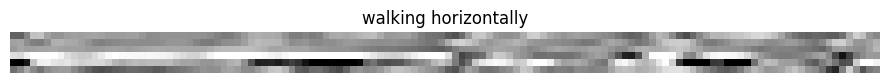

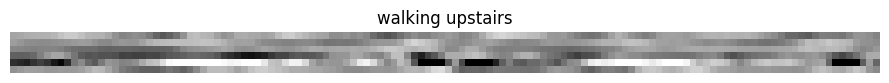

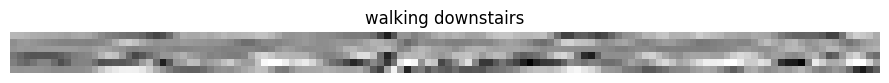

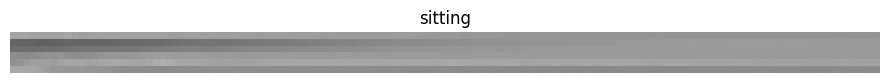

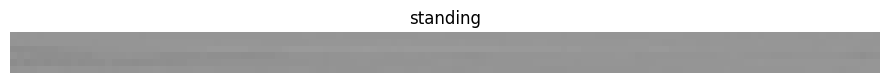

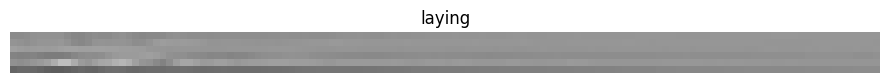

In [ ]:
import matplotlib.pyplot as plt

# Inspect some of the data by making plots

num_category = 6
def make_plots(num_examples_per_category):
    for label in range(num_category):
        x_label = x_train[y_train[:, 0]==label]
        for i in range(num_examples_per_category):
            fig, ax = plt.subplots(figsize=(9, 1))
            ax.imshow(X=x_label[100*i].T, cmap='Greys', vmin=-1, vmax=1)
            ax.axis('off')
            if i==0:
                ax.set_title(label=label_to_activity[label])
            fig.tight_layout()
    plt.show()

make_plots(num_examples_per_category=1)

#### 1D deterministic convolutional neural network

In [ ]:
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

# Create standard deterministic model with:
# - Conv1D
# - MaxPooling
# - Flatten
# - Dense with Softmax

num_category = 6
model = tf.keras.Sequential(layers=[
    tf.keras.Input(shape=(128, 6)),
    tf.keras.layers.Conv1D(filters=8, kernel_size=16,
        activation=tf.keras.activations.relu),
    tf.keras.layers.MaxPooling1D(pool_size=16),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=num_category,
        activation=tf.keras.activations.softmax)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 113, 8)         │           776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           342 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,118 (4.37 KB)

 Trainable params: 1,118 (4.37 KB)

 Non-trainable params: 0 (0.00 B)

#### Probabilistic 1D convolutional neural network, with both weight and output uncertainty

In [ ]:
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

# Replace analytical Kullback-Leibler divergence with approximated one

def kl_approx(q, p, q_tensor):
    return tf.math.reduce_mean(input_tensor=q.log_prob(value=q_tensor)
        - p.log_prob(value=q_tensor))

divergence_fn = lambda q, p, q_tensor: kl_approx(q=q, p=p, q_tensor=q_tensor)\
    / x_train.shape[0]

In [ ]:
import tf_keras
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.utils.set_random_seed(seed=42)

# Create probablistic model with the following layers:
#  - Conv1D
#  - MaxPooling
#  - Flatten
#  - Dense
#  - OneHotCategorical

divergence_fn = lambda q, p, _: tfp.distributions.kl_divergence(
    distribution_a=q, distribution_b=p) / x_train.shape[0]

num_category = 6
model = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=(128, 6)),
    tfp.layers.Convolution1DReparameterization(filters=8, kernel_size=16,
        activation=tf.keras.activations.relu,
        kernel_prior_fn=tfp.layers.default_multivariate_normal_fn,
        kernel_posterior_fn=tfp.layers.default_mean_field_normal_fn(is_singular=False),
        kernel_divergence_fn=divergence_fn,
        bias_prior_fn=tfp.layers.default_multivariate_normal_fn,
        bias_posterior_fn=tfp.layers.default_mean_field_normal_fn(is_singular=False),
        bias_divergence_fn=divergence_fn
    ),
    tf_keras.layers.MaxPooling1D(pool_size=16),
    tf_keras.layers.Flatten(),
    tfp.layers.DenseReparameterization(activation=None,
        units=tfp.layers.OneHotCategorical.params_size(event_size=num_category),
        kernel_prior_fn=tfp.layers.default_multivariate_normal_fn,
        kernel_posterior_fn=tfp.layers.default_mean_field_normal_fn(is_singular=False),
        kernel_divergence_fn=divergence_fn,
        bias_prior_fn=tfp.layers.default_multivariate_normal_fn,
        bias_posterior_fn=tfp.layers.default_mean_field_normal_fn(is_singular=False),
        bias_divergence_fn=divergence_fn
    ),
    tfp.layers.OneHotCategorical(event_size=num_category)
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_reparameterization_  (None, 113, 8)            1552      
 1 (Conv1DReparameterizatio                                      
 n)                                                              
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 7, 8)              0         
 g1D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 56)                0         
                                                                 
 dense_reparameterization_1  (None, 6)                 684       
  (DenseReparameterization)                                      
                                                                 
 one_hot_categorical_1 (One  ((None, 6),              

In [ ]:
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

# Compile the model using the negative loglikelihood

def nll(y_true, y_pred):
    return -y_pred.log_prob(value=y_true)

model.compile(
    loss=nll,
    optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.005),
    metrics=[tf_keras.metrics.CategoricalAccuracy()]
)

In [ ]:
# Train the model

model.fit(x=x_train, y=y_train_oh, epochs=20, verbose=False)
model.evaluate(x=x_test, y=y_test_oh)

93/93 [==============================] - 1s 4ms/step - loss: 0.9059 - categorical_accuracy: 0.7011


[0.9059041142463684, 0.7010518908500671]

#### Inspect model performance

In [ ]:
import matplotlib.pyplot as plt

# Define function to analyse model predictions versus true labels

num_category = 6
def analyse_model_predictions(image_num):

    # Show the accelerometer data
    print('------------------------------')
    print('Accelerometer data:')
    fig, ax = plt.subplots(figsize=(9, 1))
    ax.imshow(X=x_test[image_num].T, cmap='Greys', vmin=-1, vmax=1)
    ax.axis('off')
    plt.show()

    # Print the true activity
    print('------------------------------')
    print('True activity:', label_to_activity[y_test[image_num, 0]])
    print('')

    # Print the probabilities the model assigns
    print('------------------------------')
    print('Model estimated probabilities:')
    # Create ensemble of predicted probabilities
    predicted_probabilities = np.empty(shape=(200, num_category))
    for i in range(200):
        predicted_probabilities[i] = model(inputs=x_test[image_num]
            [np.newaxis, ...]).mean().numpy().squeeze()
    pct_2p5 = np.array([np.percentile(a=predicted_probabilities[:, i],
        q=2.5) for i in range(num_category)])
    pct_97p5 = np.array([np.percentile(a=predicted_probabilities[:, i],
        q=97.5) for i in range(num_category)])
    # Make the plots
    fig, ax = plt.subplots(figsize=(9, 3))
    bar = ax.bar(x=np.arange(num_category), height=pct_97p5, color='red')
    bar[y_test[image_num, 0]].set_color('green')
    bar = ax.bar(x=np.arange(num_category), height=pct_2p5-0.02, color='white',
        linewidth=1, edgecolor='white')
    ax.set_xticks(ticks=np.arange(num_category))
    ax.set_xticklabels(labels=[activity for activity in label_to_activity.values()],
        rotation=45, horizontalalignment='right')
    ax.set_ylim([0, 1])
    ax.set_ylabel(ylabel='Probability')
    plt.show()

------------------------------
Accelerometer data:


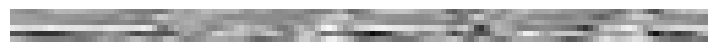

------------------------------
True activity: walking horizontally

------------------------------
Model estimated probabilities:


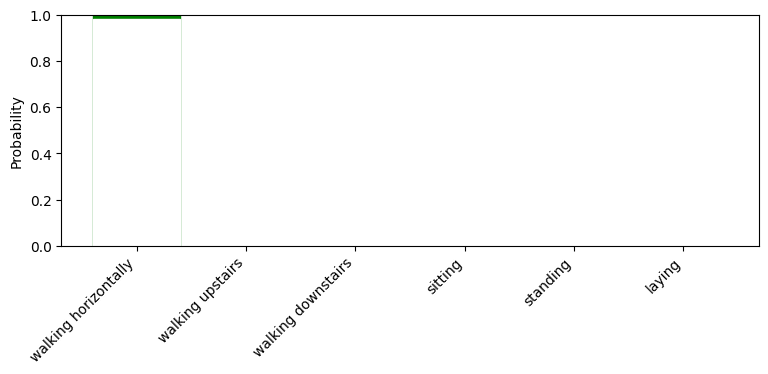

In [ ]:
analyse_model_predictions(image_num=79)

------------------------------
Accelerometer data:


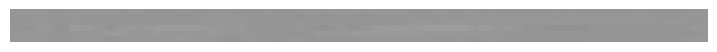

------------------------------
True activity: standing

------------------------------
Model estimated probabilities:


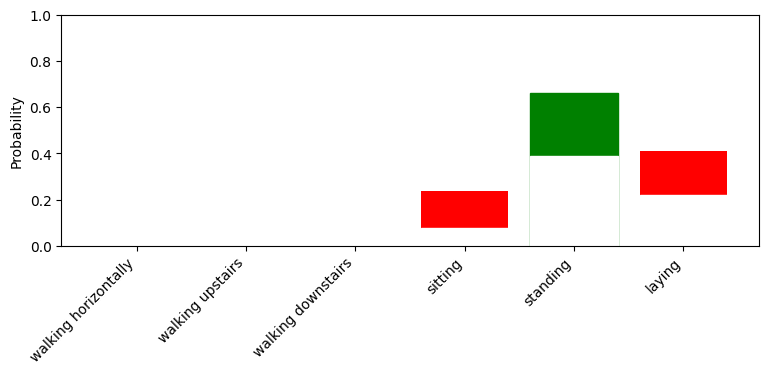

In [ ]:
analyse_model_predictions(image_num=633)

------------------------------
Accelerometer data:


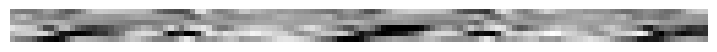

------------------------------
True activity: walking horizontally

------------------------------
Model estimated probabilities:


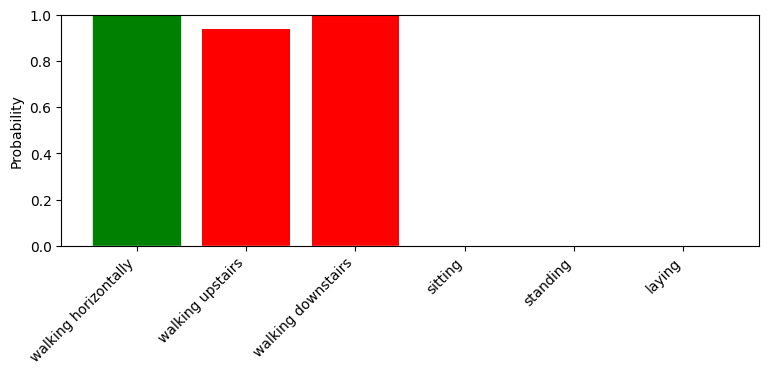

In [ ]:
analyse_model_predictions(image_num=1137)